# Preparing Data: Adding & Engineering Columns
v.ekc

Real datasets rarely arrive with every column you need and so you the data scientist but create your own! We will cover ways to add new ones and how to derive them from existing data.

| Section | Topic |
|---------|-------|
| 1 | Setup |
| 2 | Adding Independent Columns |
| 3 | Derived Columns |
| 4 | Titanic Activity |
| 5 | Open Exploration: Flight Delays |
| Appendix | Quick Reference |

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import re
sns.set_style("darkgrid")
import warnings 
warnings.filterwarnings('ignore')

---
## 2. Adding Independent Columns

Three ways to add a column that doesn't depend on existing data.



| Method | Syntax | When to use |
|--------|--------|-------------|
| Bracket assignment | `df['col'] = value` | Quickest — adds to the end |
| `.insert()` | `df.insert(pos, 'col', value)` | Need a specific column position |
| `.assign()` | `df = df.assign(col1=..., col2=...)` | Adding multiple columns at once |

### Method 1: Add to the End
### `df['new_col_name'] = [list]`

In [2]:
# Creating animals dataframe
animals_dct = {
    'Animal': ['cow', 'kitten', 'penguin', 'Puppy'],
    'Sound': ['moo', 'purr', 'chirp', 'bark'],
}

animals = pd.DataFrame(animals_dct)
animals

,Animal,Sound
0,cow,moo
1,kitten,purr
2,penguin,chirp
3,Puppy,bark


In [ ]:
# add a column on the right (broadcasting)
animals['Cute score'] = 10
animals

In [8]:
# add a column on the right (list)
animals = pd.DataFrame(animals_dct)
animals['Cute score'] = [4,10,10,7]
animals

,Animal,Sound,Cute score
0,cow,moo,4
1,kitten,purr,10
2,penguin,chirp,10
3,Puppy,bark,7


### Method 2: Insert at a Specific Position: 
### `df.insert(col_index,'new_col_name',[list])`

In [9]:
animals.insert(1, 'name', ['moomoo', 'poopoo', 'popo','doggo'])
animals

,Animal,name,Sound,Cute score
0,cow,moomoo,moo,4
1,kitten,poopoo,purr,10
2,penguin,popo,chirp,10
3,Puppy,doggo,bark,7


In [14]:
animals=animals.assign(color=['white and black','white and black','white and black', 'golden'], yum_score = [10,0,7,3])

In [13]:
animals

,Animal,name,Sound,Cute score
0,cow,moomoo,moo,4
1,kitten,poopoo,purr,10
2,penguin,popo,chirp,10
3,Puppy,doggo,bark,7


In [22]:
animals['tuxedo'] = animals.color=='white and black'
animals['Sound'] = animals['Sound'].apply(lambda x: x.upper())
animals['total score']=animals['Cute score']+ animals['yum_score']
animals['yay or neigh'] = ['yay' if score>12 else 'neigh' for score in animals['total score']]
animals

,Animal,name,Sound,Cute score,color,yum_score,tuxedo,total score,yay or neigh
0,cow,moomoo,MOO,4,white and black,10,True,14,yay
1,kitten,poopoo,PURR,10,white and black,0,True,10,neigh
2,penguin,popo,CHIRP,10,white and black,7,True,17,yay
3,Puppy,doggo,BARK,7,golden,3,False,10,neigh


In [ ]:
# Insert at a specific position with .insert(loc, column, value)
animals = pd.DataFrame(animals_dct)
animals.insert(1,'Cute score',10)
animals

In [ ]:
# or do it with a list
animals = pd.DataFrame(animals_dct)
animals.insert(1,'Cute score',[8,10,10,6])
animals

### Method 3: Add More Than One Column at Once
### `df.assign(new_col1 = [list1], new_col2=[list2])`

In [ ]:
# create two columns at once
animals = animals.assign(Adjective = ['adorable','playful','tough','cuddly'], Pet = [False,True,False,True])

In [ ]:
animals

---
### Try It 1: Build a DataFrame 😊

Create a small DataFrame with at least 4 rows (planets, foods, movies — your call).

1. Add a column to the **end** using bracket assignment (broadcast a constant).

2. Add a column at **position 1** using `.insert()`.

3. Add **two columns at once** with `.assign()`.

4. What happens if you assign a list that's the **wrong length**? Try it and note the error.

In [ ]:
# 1. Bracket assignment



In [ ]:
# 2. .insert() at position 1




In [ ]:
# 3. .assign() — two columns at once
# check original df!


In [ ]:
# 4. Wrong-length list — what error do you get?


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Any DataFrame works — here's a planets example.*

```python
# setup
planets_dct = {'Planet': ['Mercury','Venus','Earth','Mars'],
               'Moons': [0, 0, 1, 2]}
planets = pd.DataFrame(planets_dct)

# 1.
planets['Habitable'] = [False, False, True, True]

# 2.
planets.insert(1, 'Order', [1,2,3,4])

# 3.
planets = planets.assign(Rocky=True, DistAU=[0.39, 0.72, 1.0, 1.52])

# 4. ValueError: Length of values does not match length of index
planets['Bad'] = [1, 2]
```

</details>

---
## 3. Adding Columns Based on Other Columns

Six techniques for deriving a new column from existing ones.



| Technique | Example | Result |
|-----------|---------|--------|
| Boolean condition | `df['new'] = df['col'] > 5` | `True`/`False` flag |
| `.map()` | `df['new'] = df['col'].map({True:'yes', False:'no'})` | Recode values |
| `.apply()` | `df['new'] = df['col'].apply(round)` | Element-wise function |
| Arithmetic | `df['new'] = df['a'] + df['b']` | Row-wise math |
| String methods | `df['new'] = df['col'].str[0]` | String slicing/transforms |
| List comprehension | `df['new'] = ['y' if x>5 else 'n' for x in df['col']]` | Conditional logic |

In [ ]:
# Making a bool column based on condition
animals['Is Cute'] = animals['Cute score'] > 5
animals.head()

In [ ]:
# Making a categorical column based on another categorical column with map
animals['Can Own'] = animals['Pet'].map({True:'yes',False:'no'})
animals.head()

In [ ]:
# applying a function to everything in another column
animals['Rounded Score'] = animals['Cute score'].apply(round)
animals.head()

In [ ]:
# Creating new columns with element-wise arithmetic
animals['Cute & Pet'] = animals['Cute score'] + animals['Pet']
animals.head()

In [24]:
# With string methods
animals['First letter'] = animals['Animal'].str[0]
animals.head()

,Animal,name,Sound,Cute score,color,yum_score,tuxedo,total score,yay or neigh,First letter
0,cow,moomoo,MOO,4,white and black,10,True,14,yay,c
1,kitten,poopoo,PURR,10,white and black,0,True,10,neigh,k
2,penguin,popo,CHIRP,10,white and black,7,True,17,yay,p
3,Puppy,doggo,BARK,7,golden,3,False,10,neigh,P


In [25]:
# With list comprehension
animals['starts with p'] = ['yes' if re.search('[Pp]',i) else 'no' for i in animals['First letter']]
animals.head()

,Animal,name,Sound,Cute score,color,yum_score,tuxedo,total score,yay or neigh,First letter,starts with p
0,cow,moomoo,MOO,4,white and black,10,True,14,yay,c,no
1,kitten,poopoo,PURR,10,white and black,0,True,10,neigh,k,no
2,penguin,popo,CHIRP,10,white and black,7,True,17,yay,p,yes
3,Puppy,doggo,BARK,7,golden,3,False,10,neigh,P,yes


---
### Try It 2: Derived Columns 😊

Using the `animals` DataFrame:

1. Use a **boolean condition** to create `Perfect Score` — `True` if `Cute score == 10`.

2. Use **`.map()`** to recode `Pet` into 1$\rightarrow$ `'house pet'` / 0$\rightarrow$`'wild'`.

3. Use **`.apply()`** to make `Animal` all uppercase.

4. Use a **list comprehension** to create `Score Category` — `'high'` if `Cute score >= 10`, else `'low'`.

In [ ]:
# 1. Boolean: Perfect Score



In [ ]:
# 2. .map(): recode Pet




In [ ]:
# 3. .apply(): uppercase Animal names



In [ ]:
# 4. List comprehension: Score Category



<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The boolean → map two-step is one of the most common pandas patterns — you'll use it in Lab 07.*

```python
# 1.
animals['Perfect Score'] = animals['Cute score'] == 10

# 2.
animals['Pet Label'] = animals['Pet'].map({True:'house pet', False:'wild'})

# 3.
animals['Animal Upper'] = animals['Animal'].apply(str.upper)

# 4.
animals['Score Category'] = ['high' if x >= 10 else 'low' for x in animals['Cute score']]
```

</details>

---
## 4. Activity — Titanic Feature Engineering

The Seaborn Titanic dataset has columns that were *engineered* from the raw Kaggle data. Let's recreate them from scratch, then do a short EDA.

### ETL
1. Inspect dataset
2. Missing data
3. Data types
4. Summary statistics

In [26]:
# load titanic data 
titanic_seaborn = sns.load_dataset('titanic')
titanic_seaborn.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [27]:
titanic_kaggle = pd.read_csv('titanic.csv')
titanic_kaggle.head()

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Notice that some of the columns in the Seaborn version of this dataset are not included in the Kaggle version. This is because the Seaborn creators added engineered the columns (removing/adding) to make the data more interpretable and to make further analysis easier. We will replicate this process, then do a short EDA.

---
### Try It 3: Recreate the Engineered Columns 😊

1. **`alive`**: Create a column called `alive` in `titanic_kaggle` — `'no'` when `Survived` is 0, `'yes'` when `survived` is 1. Your goal is to match the `alive` column in `titanic_seaborn`. There are different ways you can do this!

2. **`alone`**: Create an `alone` column — `False` if the passenger had any family on board, `True` otherwise. (`sibsp` + `parch` > 0 means family aboard.)

3. **`who`**: Create a `who` column — `'child'` if `age < 16`, `'man'` if male and ≥ 16, `'woman'` if female and ≥ 16. *Hint: you might find it helpful to split this one up and solve in multiple lines of code.*

In [ ]:
# Activity 1: alive column



In [ ]:
# run this to check your work
(titanic_kaggle['alive'] == titanic_seaborn['alive']).all()

In [ ]:
# Activity 2: alone column



In [ ]:
# run this to check your work
(titanic_kaggle['alone'] == titanic_seaborn['alone']).all()

In [ ]:
# Activity 3: who column




In [ ]:
# run this to check your work
(titanic_kaggle['who'] == titanic_seaborn['who']).all()

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The `who` column requires `pd.isna()` to handle missing `Age` values — a good reminder that NaN handling matters when deriving columns.*

```python
# 1. alive
titanic_kaggle['alive'] = titanic_kaggle['survived'].map({0:'no', 1:'yes'})

# 2. alone
titanic_kaggle['alone'] = (titanic_kaggle['sibsp'] + titanic_kaggle['parch']) == 0

# 3. who — row-wise apply handles the NaN age check
def get_who(row):
    if pd.isna(row['age']):
        return np.nan
    elif row['age'] < 16:
        return 'child'
    elif row['sex'] == 'male':
        return 'man'
    else:
        return 'woman'

titanic_kaggle['who'] = titanic_kaggle.apply(get_who, axis=1)
```

</details>

---
### Try It 4: Survival EDA 😊

1. Use pandas to find the **number of passengers who survived vs. didn't** in each passenger class (`pclass`).

2. Create a plot showing **survival counts per `pclass`**, faceted by `sex`.

3. Create a visualization to compare the **age distribution** of survivors vs. non-survivors.

In [29]:
# 1. Survival counts by Pclass

titanic_kaggle.pclass.value_counts()


pclass
3    491
1    216
2    184
Name: count, dtype: int64

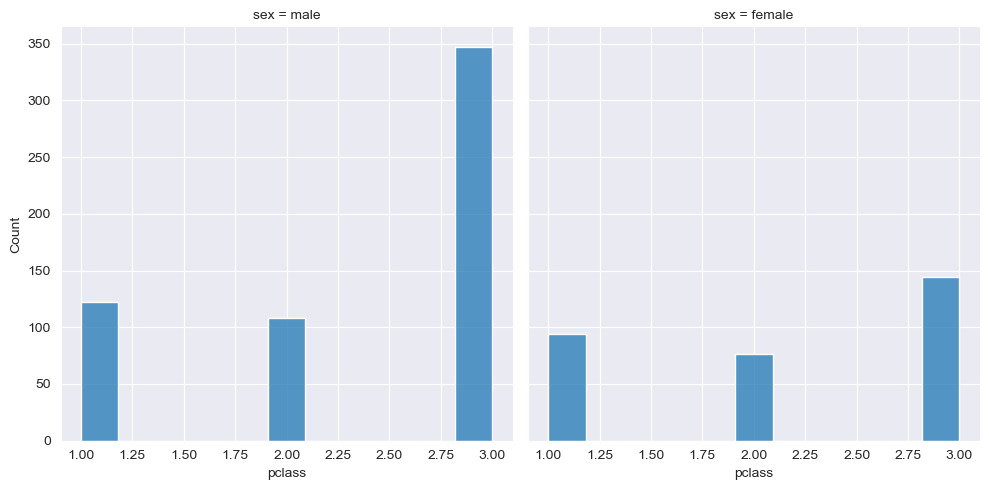

In [30]:
# 2. Plot: survival by Pclass, faceted by Sex

sns.displot(data=titanic_kaggle,
           x='pclass',
           col='sex')


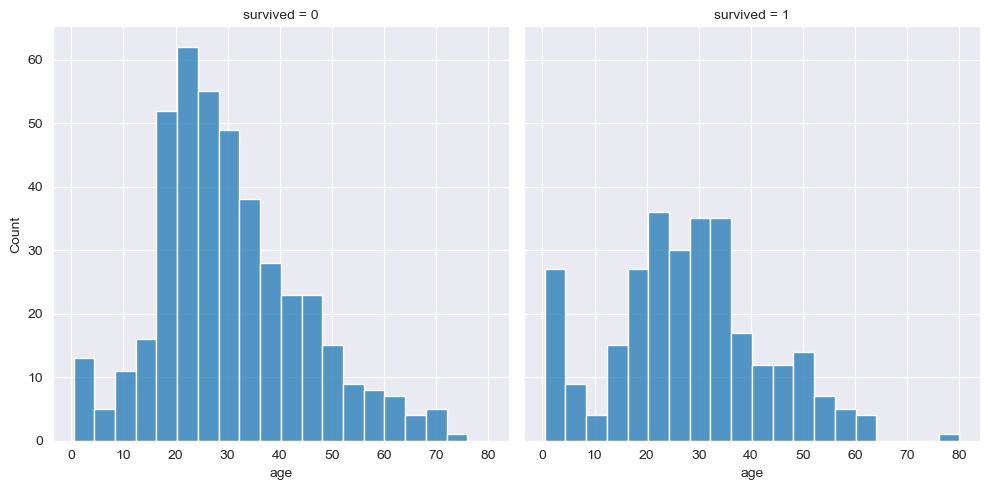

In [39]:
# 3. Age distribution: survivors vs non-survivors

sns.displot(data=titanic_kaggle,
           x='age', col='survived');


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Many right answers — the key is using `hue='survived'` or `col='sex'` to reveal the group comparison.*

```python
# 1.
titanic_kaggle.groupby(['pclass','survived']).size()

# 2.
sns.catplot(data=titanic_kaggle, x='pclass', hue='survived', col='sex', kind='count')

# 3.
sns.boxplot(data=titanic_kaggle, x='survived', y='age')
# or for distribution shape:
sns.violinplot(data=titanic_kaggle, x='survived', y='age')
```

</details>

---
## 5. 🔬 Open Exploration — Flight Delays

Practice column derivation on real data — and compare two approaches for extracting date parts.

| Column | Description |
|--------|-------------|
| `Flight_Date` | Date of the flight (string) |
| `Departure_Delay_Minutes` | Departure delay in minutes |
| `Airline`, `Origin`, `Dest` | Carrier and route info |

In [ ]:
flights = pd.read_csv('flight_delays.csv')
flights.head()

In [ ]:
flights['Year'] = flights['Flight_Date'].str.split("-").str[0]
flights.head()

In [ ]:
# Another option
flights['Flight_Date'] = pd.to_datetime(flights['Flight_Date'])
flights.dtypes

In [ ]:
flights['Year_dt'] = flights['Flight_Date'].dt.year
flights.head()

In [ ]:
flights.dtypes

**Prompt 1 — Distributions:**

Plot `Departure_Delay_Minutes` faceted by `Year_dt`. Set `xlim=(-20, 100)` to zoom in. What do you notice across years?

In [ ]:
# Prompt 1


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
sns.set(font_scale = 1.8)
fig = sns.displot(data = flights, x  = 'Departure_Delay_Minutes', col = 'Year_dt',binwidth=5)
fig.set(xlim=(-20, 100))
plt.tight_layout()
```

</details>

**Prompt 2 — String vs. Datetime:**

Run the same plot using `Year` (string) instead of `Year_dt` (int). What's different? Which would you prefer and why?

In [ ]:
# Prompt 2


<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python
sns.set(font_scale = 1.8)
fig = sns.displot(data = flights, x  = 'Departure_Delay_Minutes', col = 'Year',binwidth=5)
fig.set(xlim=(-20, 100))
plt.tight_layout()
```

</details>

**Prompt 3 — WiLdCaRd:**

Engineer at least **one new column** from `flights` (e.g., a `Month` column, a `Late` boolean, a delay category). Make a plot using it — at least 2 aesthetics or facets.

*Your interpretation: (double-click to edit)*

In [ ]:
# Prompt 3 — your choice


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*Many right answers — here's one using a `Late` boolean.*

```python
flights['Late'] = flights['Departure_Delay_Minutes'] > 15
sns.countplot(data=flights, x='Year_dt', hue='Late')
```

</details>

---
## Appendix — Column Engineering Quick Reference

### Adding independent columns
```python
df['col'] = value                          # bracket — adds to end
df.insert(pos, 'col', value)               # insert at position
df = df.assign(col1=..., col2=...)         # multiple at once
```

### Deriving columns from existing data
```python
df['new'] = df['col'] > 5                          # boolean condition
df['new'] = df['col'].map({True:'y', False:'n'})   # recode
df['new'] = df['col'].apply(round)                 # element-wise function
df['new'] = df['a'] + df['b']                      # arithmetic
df['new'] = df['col'].str.upper()                  # string methods
df['new'] = ['y' if x>5 else 'n' for x in df['col']]  # list comprehension
```

### Row-wise apply (multi-column logic)
```python
def my_func(row):
    if pd.isna(row['col']): return np.nan
    return 'result'

df['new'] = df.apply(my_func, axis=1)
```